In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

train_images = train_images.astype('float32')
test_images  = test_images.astype('float32')

mean = np.mean(train_images, axis=(0, 1, 2))
std  = np.std(train_images,  axis=(0, 1, 2))
train_images = (train_images - mean) / std
test_images  = (test_images  - mean) / std

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.15,
    height_shift_range=0.15,
    rotation_range=15,
    zoom_range=0.1,
    fill_mode='reflect'
)


def residual_block(x, filters, bottleneck=True):
    shortcut = x

    if bottleneck:
        # Сужаем каналы в 4 раза затем расширяем обратно
        inner = filters // 4

        x = layers.Conv2D(inner, 1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.Conv2D(inner, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
    else:
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

inputs = tf.keras.Input(shape=(32, 32, 3))

#Stem
x = layers.Conv2D(64, 3, padding='same', use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

#Stage 1 — 64 фильтра 3 блока
x = residual_block(x, 64, bottleneck=False)
x = residual_block(x, 64, bottleneck=False)
x = residual_block(x, 64, bottleneck=False)
x = layers.MaxPooling2D(2)(x)   # 32→16

#Stage 2 — 128 фильтров 4 блока
x = residual_block(x, 128, bottleneck=False)
x = residual_block(x, 128, bottleneck=False)
x = residual_block(x, 128, bottleneck=False)
x = residual_block(x, 128, bottleneck=False)
x = layers.MaxPooling2D(2)(x)   # 16→8

#Stage 3 — 256 фильтров 3 блока bottleneck
x = residual_block(x, 256, bottleneck=True)
x = residual_block(x, 256, bottleneck=True)
x = residual_block(x, 256, bottleneck=True)
x = layers.MaxPooling2D(2)(x)   # 8→4

#Stage 4 — 512 фильтров 2 блока bottleneck
x = residual_block(x, 512, bottleneck=True)
x = residual_block(x, 512, bottleneck=True)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

EPOCHS     = 45
BATCH_SIZE = 128
steps_per_epoch = len(train_images) // BATCH_SIZE

def lr_with_warmup(epoch):
    warmup_epochs = 5
    max_lr = 0.1
    min_lr = 1e-5
    if epoch < warmup_epochs:
        return max_lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (EPOCHS - warmup_epochs)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + np.cos(np.pi * progress))

lr_schedule = tf.keras.callbacks.LearningRateScheduler(lr_with_warmup, verbose=0)

optimizer = tf.keras.optimizers.SGD(momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

callbacks = [
    lr_schedule,
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=(test_images, test_labels),
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nТочность: {test_acc:.4f}')

Epoch 1/45
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.3055 - loss: 2.0096
Epoch 1: val_accuracy improved from None to 0.46530, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
390/390 ━━━━━━━━━━━━━━━━━━━━ 85s 164ms/step - accuracy: 0.3943 - loss: 1.6904 - val_accuracy: 0.4653 - val_loss: 1.5546 - learning_rate: 0.0200
Epoch 2/45
  1/390 ━━━━━━━━━━━━━━━━━━━━ 37s 96ms/step - accuracy: 0.4844 - loss: 1.4326

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.46530 to 0.47670, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4844 - loss: 1.4326 - val_accuracy: 0.4767 - val_loss: 1.4558 - learning_rate: 0.0400
Epoch 3/45
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5214 - loss: 1.3531
Epoch 3: val_accuracy improved from 0.47670 to 0.55690, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
390/390 ━━━━━━━━━━━━━━━━━━━━ 47s 121ms/step - accuracy: 0.5620 - loss: 1.2412 - val_accuracy: 0.5569 - val_loss: 1.3397 - learning_rate: 0.0600
Epoch 4/45
  1/390 ━━━━━━━━━━━━━━━━━━━━ 37s 95ms/step - accuracy: 0.6250 - loss: 1.0364
Epoch 4: val_accuracy did not improve from 0.55690
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6250 - loss: 1.0364 - val_accuracy: 0.5553 - val_loss: 1.3648 - learning_rate: 0.0800
Epoch 5/45
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step


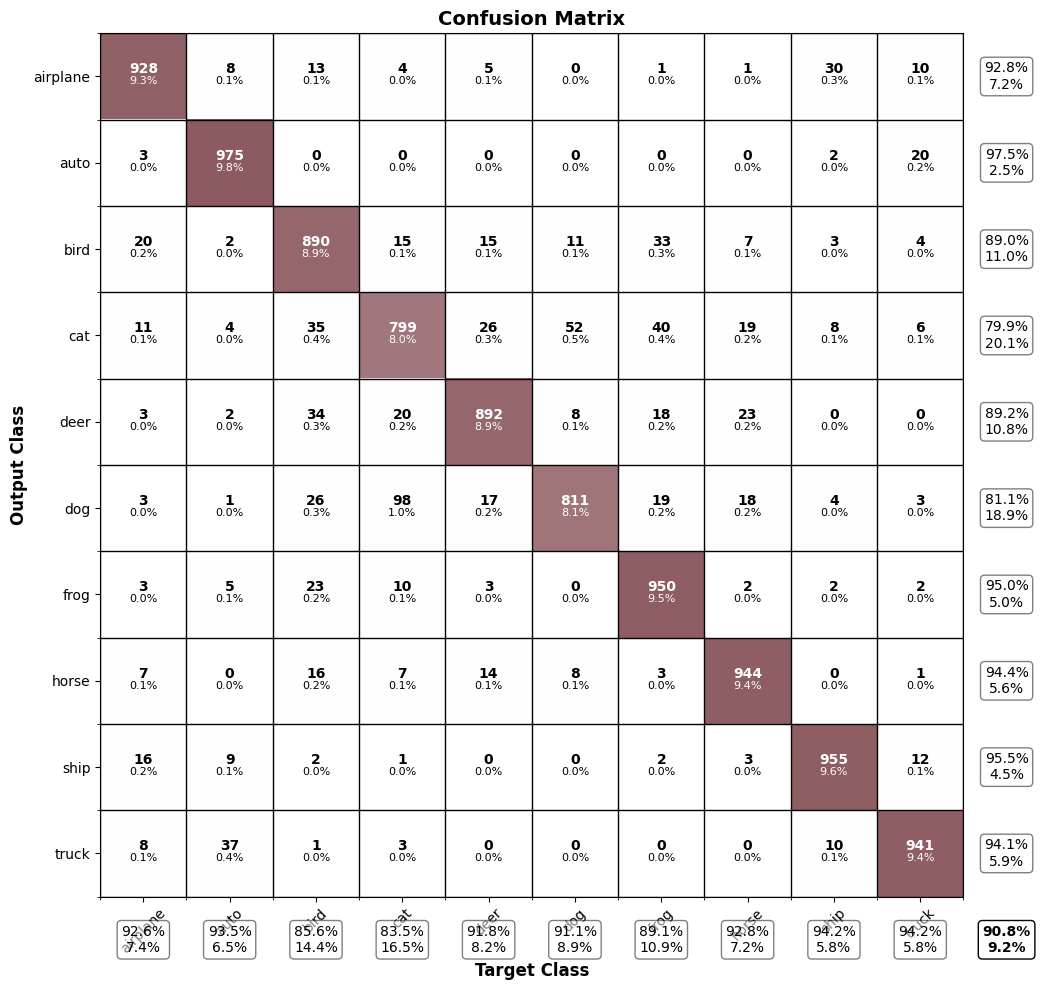

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

def plot_styled_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    total_samples = np.sum(cm)


    wine_red_cmap = LinearSegmentedColormap.from_list(
        'wine_red', ['#ffffff', '#722F37'], N=256
    )

    fig, ax = plt.subplots(figsize=(12, 10))


    ax.imshow(cm, interpolation='nearest', cmap='Greys', alpha=0.15)


    diag_mask = np.zeros_like(cm, dtype=float)
    for i in range(len(classes)):
        diag_mask[i, i] = cm[i, i]


    if diag_mask.max() > 0:
        ax.imshow(diag_mask / diag_mask.max(), interpolation='nearest',
                  cmap=wine_red_cmap, alpha=0.75)


    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = 'white' if i == j and cm[i, j] > cm.max() * 0.3 else 'black'
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="bottom",
                    fontsize=10, fontweight='bold', color=text_color)
            perc = (cm[i, j] / total_samples) * 100
            ax.text(j, i, f"{perc:.1f}%", ha="center", va="top",
                    fontsize=8, color=text_color)

    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(classes, rotation=45)
    ax.set_yticklabels(classes)

    ax.set_xticks(np.arange(-.5, len(classes), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(classes), 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)

    ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_ylabel('Output Class', fontsize=12, fontweight='bold')
    ax.set_xlabel('Target Class', fontsize=12, fontweight='bold')

    for i in range(len(classes)):
        row_total = np.sum(cm[i, :])
        row_acc = (cm[i, i] / row_total * 100) if row_total > 0 else 0
        ax.text(len(classes), i, f"{row_acc:.1f}%\n{100-row_acc:.1f}%",
                ha="center", va="center",
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

        col_total = np.sum(cm[:, i])
        col_acc = (cm[i, i] / col_total * 100) if col_total > 0 else 0
        ax.text(i, len(classes), f"{col_acc:.1f}%\n{100-col_acc:.1f}%",
                ha="center", va="center",
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    overall_acc = np.trace(cm) / total_samples * 100
    ax.text(len(classes), len(classes), f"{overall_acc:.1f}%\n{100-overall_acc:.1f}%",
            ha="center", va="center", fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white'))

    plt.tight_layout()
    plt.show()


test_predictions = model.predict(test_images)
test_predictions_labels = np.argmax(test_predictions, axis=1)

class_names = ['airplane', 'auto', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plot_styled_confusion_matrix(test_labels, test_predictions_labels, class_names)